# Unsupervised ML with an Autoencoder: train/test split and AE-only validation

This notebook trains a dense artificial neural network autoencoder (AE) on flattened Ising spin configurations. The goal is now deliberately narrow:

1. split the configurations into **training**, **validation**, and **test** data;
2. train the AE only on the training data;
3. use the validation data only for early stopping and learning-rate scheduling;
4. use the held-out test data only at the end to validate the AE as an ANN reconstruction model.

No external physical labels are used for validation. The final diagnostics answer the ANN question: **How well does the autoencoder reconstruct unseen configurations?**

Code inspired by L. Wang, Discovering Phase Transitions with Unsupervised Learning, Phys. Rev. B 94 (2016). https://doi.org/10.1103/PhysRevB.94.195105.

Code generated with assistance of ChatGPT (30 Sept 2025 and 5 May 2026)

## Set up packages and reproducibility

This cell imports the numerical, plotting, and PyTorch tools used later. It also fixes random seeds so that the train/test split and the neural-network initialization are as reproducible as possible.

Small numerical differences can still occur between CPU and GPU runs, but the code below removes the largest avoidable sources of randomness.

In [1]:
%matplotlib inline

import os
import pickle
import random
import copy

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from sklearn.model_selection import train_test_split

from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score

try:
    import pandas as pd
except ImportError:
    pd = None

try:
    from IPython.display import display
except ImportError:
    display = print

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
except ImportError as exc:
    raise ImportError(
        "This notebook uses PyTorch for the autoencoder. "
        "Install PyTorch in your notebook environment and rerun this cell."
    ) from exc

# ---------- Reproducibility ----------
seed = 42
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Deterministic algorithms improve reproducibility when available.
# warn_only=True keeps the notebook portable on systems where a deterministic
# implementation of a specific operation is not available.
try:
    torch.use_deterministic_algorithms(True, warn_only=True)
except Exception:
    pass

mpl.rcParams["text.usetex"] = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch version:", torch.__version__)
print("Training device:", device)

PyTorch version: 2.1.2+cu121
Training device: cuda


## Load and flatten the spin configurations

The pickle file is expected to contain a dictionary whose values are lists of spin configurations. For this AE-only version, the dictionary keys are used only to access the stored batches. They are **not** used as input labels, prediction targets, colors, or validation quantities.

Each configuration is reshaped into one long vector of length \(N^2\). The resulting data matrix has shape

\[
\text{number of configurations} \times \text{number of lattice sites}.
\]

The autoencoder will later learn to map each vector to a low-dimensional bottleneck and back to the original vector.

In [2]:
N = 80
samples_per_batch = 100
pkl_path = f"mc_samples_{N}.pickle"

if not os.path.exists(pkl_path):
    raise FileNotFoundError(
        f"Could not find {pkl_path!r} in the current working directory. "
        "Place the pickle file next to this notebook or update pkl_path."
    )

with open(pkl_path, "rb") as f:
    data = pickle.load(f)

batch_keys = sorted(data.keys())
flat_size = N * N

def key_to_temperature(key):
    """
    Convert the dictionary key into a numeric temperature.
    Adjust this helper if your pickle uses a more complicated key format.
    """
    return float(key)

total_samples = sum(min(samples_per_batch, len(data[key])) for key in batch_keys)

lattice_bank = np.empty((total_samples, flat_size), dtype=np.int8)
temperature_bank = np.empty(total_samples, dtype=np.float32)

row = 0
for key in batch_keys:
    cfgs = data[key][:samples_per_batch]
    temp_value = key_to_temperature(key)

    for cfg in cfgs:
        lattice_bank[row] = np.asarray(cfg, dtype=np.int8).reshape(-1)
        temperature_bank[row] = temp_value
        row += 1

print("Number of batches in file:", len(batch_keys))
print("lattice_bank shape:      ", lattice_bank.shape)
print("temperature_bank shape:  ", temperature_bank.shape)

Number of batches in file: 14
lattice_bank shape:       (1400, 6400)
temperature_bank shape:   (1400,)


## Prepare spin values and split into train, validation, and test data

The AE input is the spin configuration itself. The AE target is also the same spin configuration. This is why the training dataset later stores each array twice: once as input and once as reconstruction target.

The split has three parts:

- **training set**: used to update the neural-network weights;
- **validation set**: used during training for early stopping and learning-rate scheduling;
- **test set**: kept completely separate until the final AE validation.

The test set is the important part for the final question: it estimates how well the trained AE reconstructs configurations it did not see during fitting.

In [3]:
# The dense AE is trained directly on spin values in {-1, +1}.
# This is better matched to the data than standardizing each lattice site separately,
# because the output layer uses tanh and therefore naturally reconstructs values in [-1, 1].
X_spins = lattice_bank.astype(np.float32)
T_all = temperature_bank.astype(np.float32)

# Robustly handle data stored as {0, 1} instead of {-1, +1}.
unique_spin_values = np.unique(X_spins)
if set(np.round(unique_spin_values).astype(int)).issubset({0, 1}):
    X_spins = 2.0 * X_spins - 1.0

test_fraction = 0.20
X_train_full, X_test, T_train_full, T_test = train_test_split(
    X_spins,
    T_all,
    test_size=test_fraction,
    random_state=seed,
    shuffle=True,
)

validation_fraction_of_train_full = 0.15
X_train, X_val, T_train, T_val = train_test_split(
    X_train_full,
    T_train_full,
    test_size=validation_fraction_of_train_full,
    random_state=seed,
    shuffle=True,
)

print("Full data shape:       ", X_spins.shape)
print("Training data shape:   ", X_train.shape)
print("Validation data shape: ", X_val.shape)
print("Test data shape:       ", X_test.shape)

Full data shape:        (1400, 6400)
Training data shape:    (952, 6400)
Validation data shape:  (168, 6400)
Test data shape:        (280, 6400)


## Define the dense autoencoder

The model has two parts:

- the **encoder**, which compresses a \(6400\)-dimensional spin vector to a small latent vector;
- the **decoder**, which reconstructs the original spin vector from that latent vector.

The bottleneck has only five neurons. This forces the network to keep only information that is useful for reconstruction instead of simply copying the input through a wide hidden representation.

The model is still a simple ANN autoencoder: it uses dense layers, ReLU activations inside the network, and a tanh output layer because the desired reconstructed values are spin-like numbers between \(-1\) and \(+1\).

In [4]:
input_dim = X_spins.shape[1]
latent_dim = 5
noise_std = 0.05
l2_strength = 1e-6

class DenseSpinAutoencoder(nn.Module):
    """Dense autoencoder for flattened spin configurations.

    During training, a small amount of Gaussian noise is added to the input.
    This makes the task slightly harder and encourages the bottleneck to encode
    robust information rather than memorizing individual spins.
    """

    def __init__(self, input_dim, latent_dim=5, noise_std=0.05):
        super().__init__()
        self.noise_std = noise_std

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.ReLU(),
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim),
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 1024),
            nn.ReLU(),
            nn.Linear(1024, input_dim),
            nn.Tanh(),
        )

    def forward(self, x):
        # Noise is applied only in training mode. It is not applied during
        # validation, testing, or latent-space encoding.
        if self.training and self.noise_std > 0:
            x = x + self.noise_std * torch.randn_like(x)
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

    @torch.no_grad()
    def encode(self, x):
        self.eval()
        return self.encoder(x)

model = DenseSpinAutoencoder(
    input_dim=input_dim,
    latent_dim=latent_dim,
    noise_std=noise_std,
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=l2_strength)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=10,
    min_lr=1e-5,
)

print(model)

DenseSpinAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=6400, out_features=1024, bias=True)
    (1): ReLU()
    (2): Linear(in_features=1024, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=5, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=5, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=1024, bias=True)
    (5): ReLU()
    (6): Linear(in_features=1024, out_features=6400, bias=True)
    (7): Tanh()
  )
)


## Train the autoencoder

For an autoencoder, the target is the input itself. The loss is therefore the mean squared difference between the original spin vector $x$ and its reconstruction $\hat{x}$:

$\mathrm{MSE}=\frac{1}{D}\sum_{j=1}^{D}(x_j-\hat{x}_j)^2.$

The training loop performs the following steps in each epoch:

1. pass training batches through the AE;
2. compute reconstruction MSE;
3. update the network weights by backpropagation;
4. evaluate reconstruction MSE on the validation set;
5. keep a copy of the model with the best validation loss;
6. stop early if validation loss no longer improves.

The held-out test data are not used here.

In [5]:
batch_size = 64

train_tensor = torch.from_numpy(X_train).float()
val_tensor = torch.from_numpy(X_val).float()

train_loader = DataLoader(
    TensorDataset(train_tensor, train_tensor),
    batch_size=batch_size,
    shuffle=True,
    generator=torch.Generator().manual_seed(seed),
    num_workers=0,
)
val_loader = DataLoader(
    TensorDataset(val_tensor, val_tensor),
    batch_size=128,
    shuffle=False,
    num_workers=0,
)

max_epochs = 250
patience = 25
min_delta = 1e-5

best_val_loss = np.inf
best_state_dict = copy.deepcopy(model.state_dict())
epochs_without_improvement = 0
history = {"loss": [], "val_loss": []}

for epoch in range(1, max_epochs + 1):
    # ----- Training pass -----
    model.train()
    train_loss_sum = 0.0
    train_count = 0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad(set_to_none=True)
        yhat = model(xb)
        loss = criterion(yhat, yb)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * xb.size(0)
        train_count += xb.size(0)

    train_loss = train_loss_sum / train_count

    # ----- Validation pass -----
    model.eval()
    val_loss_sum = 0.0
    val_count = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            yhat = model(xb)
            loss = criterion(yhat, yb)
            val_loss_sum += loss.item() * xb.size(0)
            val_count += xb.size(0)

    val_loss = val_loss_sum / val_count
    history["loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    scheduler.step(val_loss)

    # Keep the best validation model. This avoids returning a late-epoch model
    # that overfit the training data after validation performance stopped improving.
    if val_loss < best_val_loss - min_delta:
        best_val_loss = val_loss
        best_state_dict = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epoch == 1 or epoch % 10 == 0 or epochs_without_improvement == 0:
        current_lr = optimizer.param_groups[0]["lr"]
        print(
            f"Epoch {epoch:03d} | train MSE {train_loss:.5f} | "
            f"val MSE {val_loss:.5f} | lr {current_lr:.1e}"
        )

    if epochs_without_improvement >= patience:
        print(f"Early stopping after {epoch} epochs. Best validation MSE: {best_val_loss:.5f}")
        break

model.load_state_dict(best_state_dict)
model.eval()

print(f"Training stopped after {len(history['loss'])} epochs.")
print(f"Final training loss:  {history['loss'][-1]:.5f}")
print(f"Best validation loss: {best_val_loss:.5f}")

d:\python_envs\DL_cuda\Lib\site-packages\torch\nn\modules\linear.py:114: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#cublasApi_reproducibility (Triggered internally at ..\aten\src\ATen\Context.cpp:156.)
  return F.linear(input, self.weight, self.bias)
d:\python_envs\DL_cuda\Lib\site-packages\torch\autograd\__init__.py:251: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it us

Epoch 001 | train MSE 0.85960 | val MSE 0.76082 | lr 1.0e-03
Epoch 002 | train MSE 0.73583 | val MSE 0.74018 | lr 1.0e-03
Epoch 003 | train MSE 0.72159 | val MSE 0.73358 | lr 1.0e-03
Epoch 004 | train MSE 0.70108 | val MSE 0.72500 | lr 1.0e-03
Epoch 005 | train MSE 0.68315 | val MSE 0.70626 | lr 1.0e-03
Epoch 006 | train MSE 0.66609 | val MSE 0.69460 | lr 1.0e-03
Epoch 007 | train MSE 0.64251 | val MSE 0.68088 | lr 1.0e-03
Epoch 008 | train MSE 0.62984 | val MSE 0.67656 | lr 1.0e-03
Epoch 009 | train MSE 0.62158 | val MSE 0.67251 | lr 1.0e-03
Epoch 010 | train MSE 0.61571 | val MSE 0.67460 | lr 1.0e-03
Epoch 012 | train MSE 0.60510 | val MSE 0.67097 | lr 1.0e-03
Epoch 020 | train MSE 0.57655 | val MSE 0.68213 | lr 1.0e-03
Epoch 030 | train MSE 0.51686 | val MSE 0.70977 | lr 5.0e-04
Early stopping after 37 epochs. Best validation MSE: 0.67097
Training stopped after 37 epochs.
Final training loss:  0.48295
Best validation loss: 0.67097


In [6]:
# ---------- Optional post-hoc latent-space probe: |M| from the AE bottleneck ----------
# This section uses magnetization only after the AE has been trained.
# It does not change the AE weights and it is not part of the AE validation loss.

# Compute M from the original spin configurations for each split.
def magnetization_sum(X):
    """
    Signed total magnetization per configuration:
        M = sum_i s_i
    for each lattice configuration.
    """
    return X.sum(axis=1)

mag_train = magnetization_sum(X_train)
mag_test = magnetization_sum(X_test)


@torch.no_grad()
def encode_dataset(model, X, batch_size=128):
    """Encode a NumPy data matrix into the AE bottleneck."""
    model.eval()
    tensor = torch.from_numpy(X).float()
    loader = DataLoader(TensorDataset(tensor), batch_size=batch_size, shuffle=False, num_workers=0)

    latent_batches = []
    for (xb,) in loader:
        xb = xb.to(device)
        z = model.encode(xb)
        latent_batches.append(z.cpu().numpy())

    return np.vstack(latent_batches)

# Encode each split into the 5-D AE bottleneck.
latent_train = encode_dataset(model, X_train)
latent_val = encode_dataset(model, X_val)
latent_test = encode_dataset(model, X_test)

print("Latent-space shapes:")
print("  train:     ", latent_train.shape)
print("  validation:", latent_val.shape)
print("  test:      ", latent_test.shape)

Latent-space shapes:
  train:      (952, 5)
  validation: (168, 5)
  test:       (280, 5)


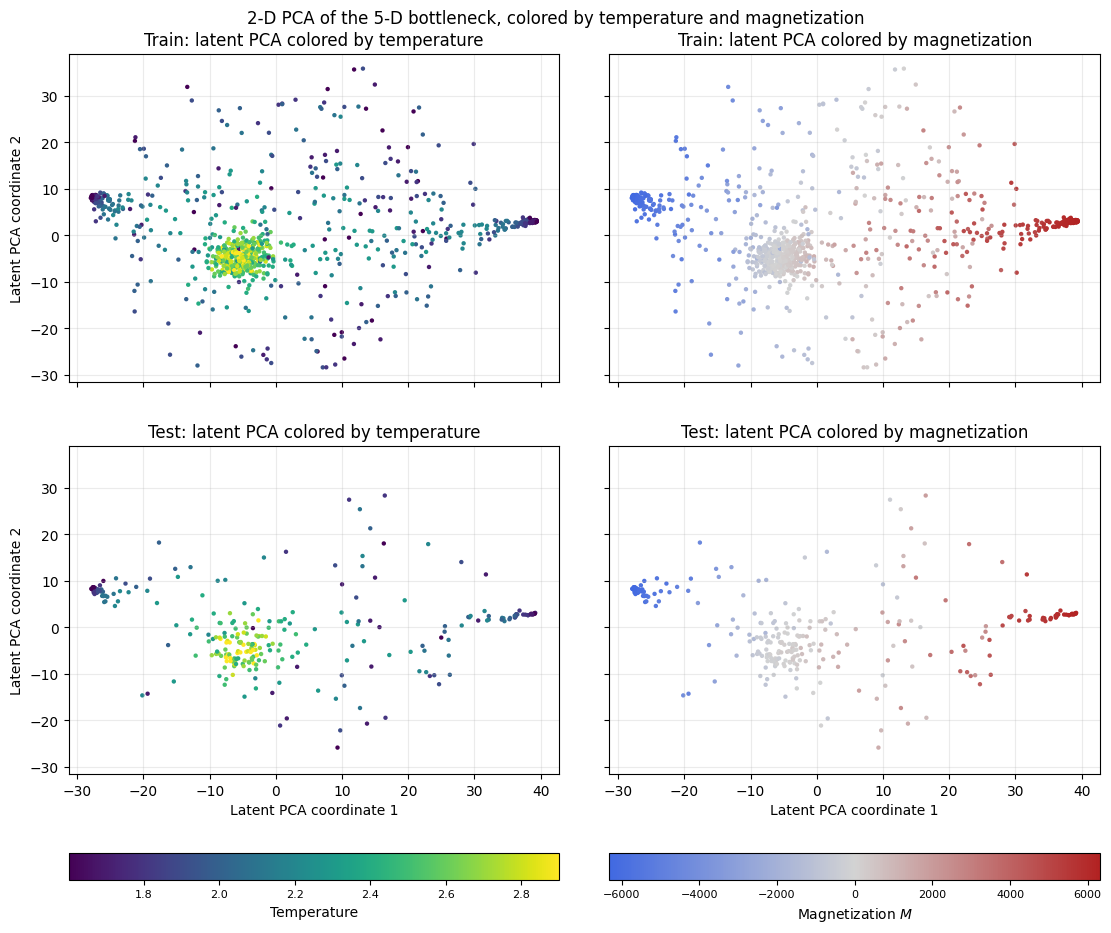

In [13]:
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm, Normalize

# ---------- Visualization: 5-D bottleneck projected to 2-D with PCA ----------
pca = PCA(n_components=2, random_state=seed)
latent_train_2d = pca.fit_transform(latent_train)
latent_test_2d = pca.transform(latent_test)

# Signed magnetization sum
mag_train = magnetization_sum(X_train)
mag_test = magnetization_sum(X_test)

# Shared temperature normalization for train and test
temp_norm = Normalize(
    vmin=min(np.min(T_train), np.min(T_test)),
    vmax=max(np.max(T_train), np.max(T_test))
)

# Blue -> grey -> red colormap for signed magnetization
blue_grey_red = LinearSegmentedColormap.from_list(
    "blue_grey_red",
    ["royalblue", "lightgrey", "firebrick"]
)

# Center magnetization colormap at zero
mag_lim = max(np.abs(mag_train).max(), np.abs(mag_test).max())
mag_norm = TwoSlopeNorm(vmin=-mag_lim, vcenter=0.0, vmax=mag_lim)

# Figure with an extra row for the colorbars
fig = plt.figure(figsize=(11, 9), constrained_layout=True)

gs = fig.add_gridspec(
    nrows=3,
    ncols=2,
    height_ratios=[1, 1, 0.08],
    hspace=0.12,
    wspace=0.08
)

axes = np.empty((2, 2), dtype=object)

axes[0, 0] = fig.add_subplot(gs[0, 0])
axes[0, 1] = fig.add_subplot(gs[0, 1], sharex=axes[0, 0], sharey=axes[0, 0])
axes[1, 0] = fig.add_subplot(gs[1, 0], sharex=axes[0, 0], sharey=axes[0, 0])
axes[1, 1] = fig.add_subplot(gs[1, 1], sharex=axes[0, 0], sharey=axes[0, 0])

cax_temp = fig.add_subplot(gs[2, 0])
cax_mag = fig.add_subplot(gs[2, 1])

# ---- Row 1: training data ----
sc_train_temp = axes[0, 0].scatter(
    latent_train_2d[:, 0],
    latent_train_2d[:, 1],
    c=T_train,
    s=10,
    cmap="viridis",
    norm=temp_norm,
    edgecolors="none"
)
axes[0, 0].set_title("Train: latent PCA colored by temperature")
axes[0, 0].set_ylabel("Latent PCA coordinate 2")
axes[0, 0].grid(alpha=0.25)

sc_train_mag = axes[0, 1].scatter(
    latent_train_2d[:, 0],
    latent_train_2d[:, 1],
    c=mag_train,
    s=10,
    cmap=blue_grey_red,
    norm=mag_norm,
    edgecolors="none"
)
axes[0, 1].set_title("Train: latent PCA colored by magnetization")
axes[0, 1].grid(alpha=0.25)

# ---- Row 2: test data ----
sc_test_temp = axes[1, 0].scatter(
    latent_test_2d[:, 0],
    latent_test_2d[:, 1],
    c=T_test,
    s=10,
    cmap="viridis",
    norm=temp_norm,
    edgecolors="none"
)
axes[1, 0].set_title("Test: latent PCA colored by temperature")
axes[1, 0].set_xlabel("Latent PCA coordinate 1")
axes[1, 0].set_ylabel("Latent PCA coordinate 2")
axes[1, 0].grid(alpha=0.25)

sc_test_mag = axes[1, 1].scatter(
    latent_test_2d[:, 0],
    latent_test_2d[:, 1],
    c=mag_test,
    s=10,
    cmap=blue_grey_red,
    norm=mag_norm,
    edgecolors="none"
)
axes[1, 1].set_title("Test: latent PCA colored by magnetization")
axes[1, 1].set_xlabel("Latent PCA coordinate 1")
axes[1, 1].grid(alpha=0.25)

# Hide repeated tick labels for a cleaner shared-axis layout
for ax in axes[0, :]:
    ax.tick_params(labelbottom=False)

for ax in axes[:, 1]:
    ax.tick_params(labelleft=False)

# ---- Horizontal colorbars below each column ----
cbar_temp = fig.colorbar(
    sc_train_temp,
    cax=cax_temp,
    orientation="horizontal"
)
cbar_temp.set_label("Temperature")
cbar_temp.ax.tick_params(labelsize=8)

cbar_mag = fig.colorbar(
    sc_train_mag,
    cax=cax_mag,
    orientation="horizontal"
)
cbar_mag.set_label("Magnetization $M$")
cbar_mag.ax.tick_params(labelsize=8)

fig.suptitle(
    "2-D PCA of the 5-D bottleneck, colored by temperature and magnetization",
    y=1.02
)

fig.savefig(
    "ae_latent_pca_2x2_train_test_temperature_magnetization.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [9]:
# ---------- Regression probe: predict the order-parameter magnitude |M| ----------
# This is a post-hoc probe of the learned AE bottleneck.
#
# Important:
# The autoencoder was not trained to predict magnetization.
# We now ask whether the learned 5-D bottleneck contains enough information
# that a simple supervised readout can recover the physical order parameter.
#
# We use |M| rather than signed M because |M| is the standard finite-size
# order-parameter magnitude for the Ising model. The two ferromagnetic branches
# have opposite signs of M, but both correspond to large |M|.
#
# A quadratic readout is used because the latent space can contain two
# symmetry-related ordered branches. A purely linear model may not be able to
# map both branches to the same large value of |M|.

def magnetization_sum(X):
    """
    Signed total magnetization per configuration:
        M = sum_i s_i
    """
    return X.sum(axis=1)


def magnetization_abs(X):
    """
    Order-parameter magnitude per configuration:
        |M| = |sum_i s_i|
    """
    return np.abs(magnetization_sum(X))


# Use the order-parameter magnitude as target.
mag_abs_train = magnetization_abs(X_train)
mag_abs_val = magnetization_abs(X_val)
mag_abs_test = magnetization_abs(X_test)

# Optional normalization:
# Divide by the number of spins so that |m| lies approximately in [0, 1].
# This does not change R^2, but makes MAE/RMSE easier to interpret.
n_spins = X_train.shape[1]

mag_abs_train_norm = mag_abs_train / n_spins
mag_abs_val_norm = mag_abs_val / n_spins
mag_abs_test_norm = mag_abs_test / n_spins


# Quadratic ridge readout.
# The polynomial terms allow the probe to represent curved and symmetric
# relations in the latent space.
ridge_alphas = np.logspace(-6, 6, 25)

order_parameter_probe = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(degree=2, include_bias=False),
    StandardScaler(),
    RidgeCV(alphas=ridge_alphas),
)

# Fit only on the training data.
order_parameter_probe.fit(latent_train, mag_abs_train_norm)

latent_by_split = {
    "train": latent_train,
    "validation": latent_val,
    "test": latent_test,
}

mag_abs_by_split = {
    "train": mag_abs_train_norm,
    "validation": mag_abs_val_norm,
    "test": mag_abs_test_norm,
}

probe_rows = []
mag_abs_predictions = {}

for split_name in ["train", "validation", "test"]:
    y_true = mag_abs_by_split[split_name]
    y_pred = order_parameter_probe.predict(latent_by_split[split_name])
    mag_abs_predictions[split_name] = y_pred

    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))

    probe_rows.append({
        "split": split_name,
        "R2": r2,
        "MAE(|m|)": mae,
        "RMSE(|m|)": rmse,
    })

print("\nQuadratic probe: predicting normalized order-parameter magnitude |m| from the 5-D AE bottleneck")

if pd is not None:
    order_parameter_probe_table = pd.DataFrame(probe_rows)
    display(order_parameter_probe_table)
else:
    for row in probe_rows:
        print(row)

selected_alpha = order_parameter_probe.named_steps["ridgecv"].alpha_
print(f"Selected ridge alpha: {selected_alpha:.3e}")


Quadratic probe: predicting normalized order-parameter magnitude |m| from the 5-D AE bottleneck


,split,R2,MAE(|m|),RMSE(|m|)
0,train,0.930862,0.074443,0.097283
1,validation,0.952447,0.060671,0.081103
2,test,0.959711,0.059777,0.075697


Selected ridge alpha: 1.000e-01


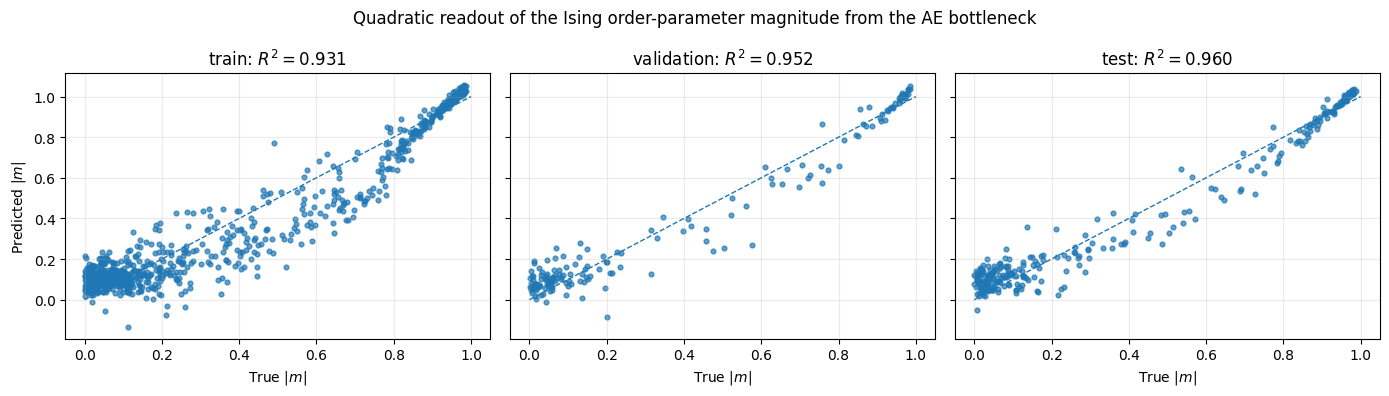

In [10]:
# ---------- Diagnostic plot: predicted vs true |m| ----------

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True, sharey=True)

for ax, split_name in zip(axes, ["train", "validation", "test"]):
    y_true = mag_abs_by_split[split_name]
    y_pred = mag_abs_predictions[split_name]

    ax.scatter(y_true, y_pred, s=12, alpha=0.7)
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)

    r2 = r2_score(y_true, y_pred)
    ax.set_title(f"{split_name}: $R^2={r2:.3f}$")
    ax.set_xlabel("True $|m|$")
    ax.grid(alpha=0.25)

axes[0].set_ylabel("Predicted $|m|$")

fig.suptitle("Quadratic readout of the Ising order-parameter magnitude from the AE bottleneck")
plt.tight_layout()
fig.savefig("ae_quadratic_probe_predicted_vs_true_abs_magnetization.png",
            dpi=300, bbox_inches="tight")
plt.show()